In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report

df = pd.read_csv('fitness_dataset_linear.csv')
df['smokes'] = df['smokes'].replace({'0': 'no', '1': 'yes'})

df['smokes_num'] = df['smokes'].map({'no': 0, 'yes': 1})
sleep_temp = df['sleep_hours'].fillna(df['sleep_hours'].median())

score = (
    (df['activity_index'] * 3.0) + 
    (df['nutrition_quality'] * 2.0) + 
    (sleep_temp * 1.5) - 
    (df['age'] * 0.1) - 
    (df['smokes_num'] * 4.0)
)

df['is_fit'] = (score > score.median()).astype(int)
df = df.drop(columns=['smokes_num'])
df.to_csv('fitness_dataset_linear.csv', index=False)

X = df.drop(columns=['is_fit'])
y = df['is_fit']

num_features = ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours', 'nutrition_quality', 'activity_index']
cat_features = ['smokes', 'gender']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', OneHotEncoder(drop='first'), cat_features)
])

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', Perceptron(random_state=42))])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)
print("Modelo Baseline: Classificador Linear com Perceptron:\n")
print(classification_report(y_test, pipeline.predict(X_test)))

Modelo Baseline: Classificador Linear com Perceptron:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       300
           1       1.00      0.97      0.98       300

    accuracy                           0.98       600
   macro avg       0.99      0.98      0.98       600
weighted avg       0.99      0.98      0.98       600



In [3]:
pesos = pipeline.named_steps['classifier'].coef_[0]
bias = pipeline.named_steps['classifier'].intercept_[0]

features = num_features + ['smokes_yes', 'gender_M']
for f, p in zip(features, pesos):
    print(f"{f}: {p:.2f}")

print(f"\nBias (Ponto de partida): {bias:.2f}")

age: -13.43
height_cm: 1.25
weight_kg: 0.63
heart_rate: 1.53
blood_pressure: -0.06
sleep_hours: 15.79
nutrition_quality: 40.10
activity_index: 24.46
smokes_yes: -27.00
gender_M: 0.00

Bias (Ponto de partida): 11.00


Modelo com Árvore de Decisão:

              precision    recall  f1-score   support

           0       0.78      0.90      0.84       300
           1       0.89      0.75      0.81       300

    accuracy                           0.82       600
   macro avg       0.83      0.82      0.82       600
weighted avg       0.83      0.82      0.82       600



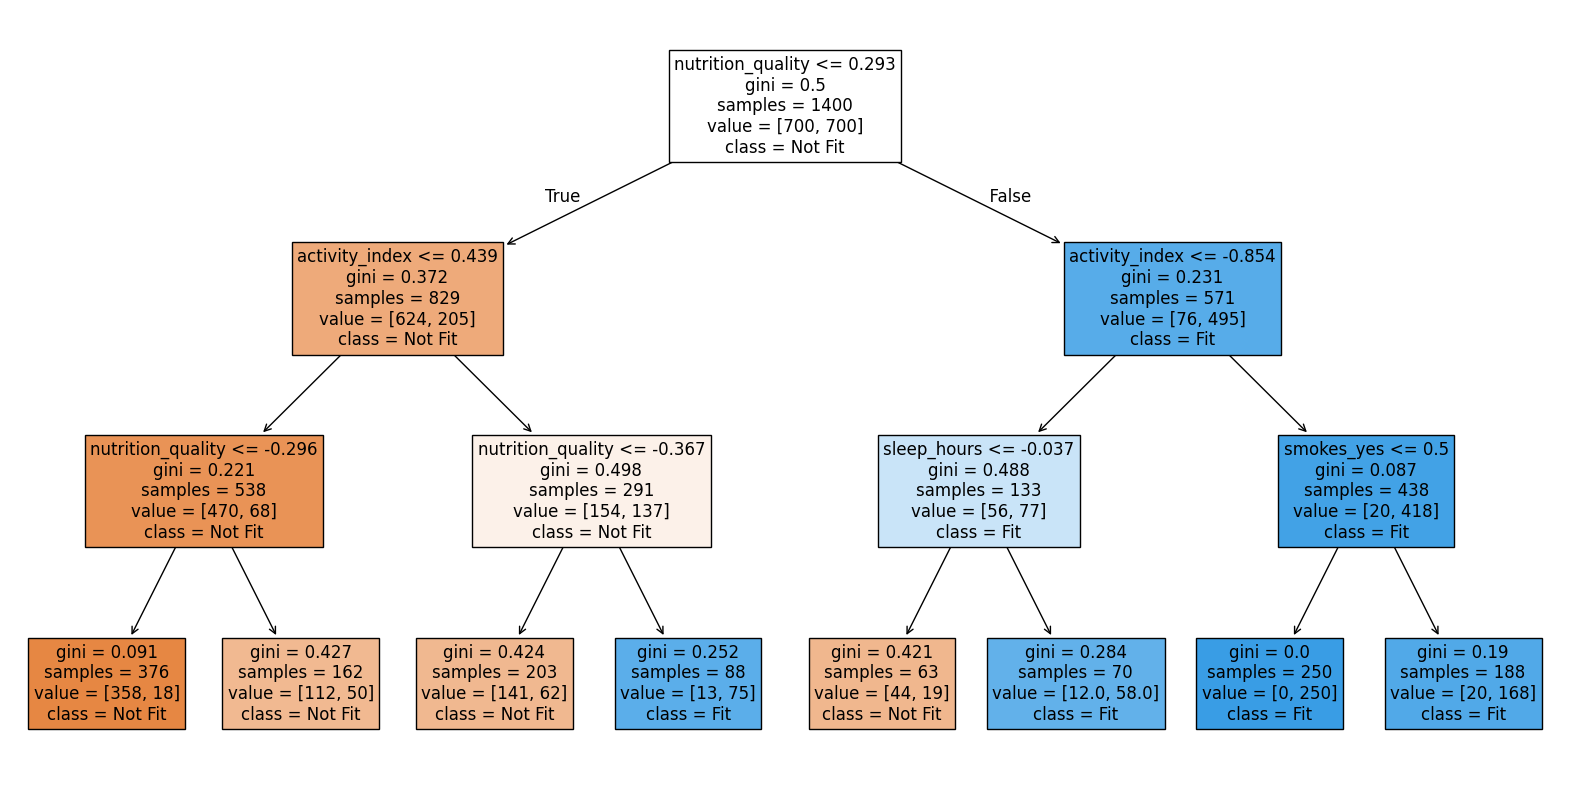

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor), # Reutiliza o preprocessor definido na etapa anterior
    ('classifier', DecisionTreeClassifier(max_depth=3, random_state=42)) # Profundidade curta para regras claras
])

pipeline_tree.fit(X_train, y_train)

y_pred_tree = pipeline_tree.predict(X_test)
print("Modelo com Árvore de Decisão:\n")
print(classification_report(y_test, y_pred_tree))

plt.figure(figsize=(20,10))
feat_names = num_features + ['smokes_yes', 'gender_M']
plot_tree(pipeline_tree.named_steps['classifier'], 
          feature_names=feat_names, 
          class_names=['Not Fit', 'Fit'], 
          filled=True, fontsize=12)
plt.show()

In [5]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'classifier__max_depth': [3, 4, 5, 6, 8, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}


grid_search = GridSearchCV(
    pipeline_tree, 
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor acurácia na validação cruzada: {grid_search.best_score_:.4f}")


best_tree = grid_search.best_estimator_
y_pred_opt = best_tree.predict(X_test)

print("\nRelatório - Árvore de Decisão Otimizada:\n")
print(classification_report(y_test, y_pred_opt))

Melhores parâmetros encontrados: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_split': 10}
Melhor acurácia na validação cruzada: 0.8764

Relatório - Árvore de Decisão Otimizada:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       300
           1       0.89      0.87      0.88       300

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.88      0.88      0.88       600



In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Pipeline
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}


grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)


best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nRandom Forest Otimizada\n")
print(classification_report(y_test, y_pred_rf))


importances = best_rf.named_steps['classifier'].feature_importances_
feat_names = num_features + ['smokes_yes', 'gender_M']
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nImportância das Features")
print(importance_df)


Random Forest Otimizada

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       300
           1       0.94      0.92      0.93       300

    accuracy                           0.93       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600


Importância das Features
             Feature  Importance
6  nutrition_quality    0.506599
7     activity_index    0.168732
5        sleep_hours    0.081803
0                age    0.075675
8         smokes_yes    0.035521
4     blood_pressure    0.035239
3         heart_rate    0.033335
2          weight_kg    0.030524
1          height_cm    0.028389
9           gender_M    0.004182
